This project addresses a common challenge faced by HR departments: **manually screening thousands of resumes** for job openings. This process is not only time-consuming but also prone to human bias and error.

To solve this, we developed an **AI-based Resume Screening System** that leverages Natural Language Processing (NLP) and Machine Learning (ML) techniques to:

- Automatically read `.docx` format resumes
- Clean and process the resume text using NLP
- Predict the most suitable job category based on resume content

The solution is deployed as a user-friendly web app using **Streamlit**, where HR personnel can upload resumes and instantly receive **job role predictions**, such as “Web Developer” or “Data Analyst”.

### 🚀 Key Features
- End-to-end automation: from raw resume to prediction
- Trained classification model using TF-IDF + Logistic Regression
- Deployable interface via Streamlit for real-time predictions

 Install python-docx to read text from .docx resumes or report.

In [1]:
!pip install python-docx

# Import DataSet

In [3]:
import os
import pandas as pd
from docx import Document

# ✅ Correct path to folder (not to .csv file)
folder_path = r'C:\Users\DELL\Downloads\archive.csv\Resumes'  # Use raw string

# List to store file content
data = []

# Loop through all .docx files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.docx'):
        file_path = os.path.join(folder_path, filename)
        doc = Document(file_path)
        
        # Extract text
        full_text = "\n".join([para.text for para in doc.paragraphs])
        
        # Append to list
        data.append({
            'filename': filename,
            'content': full_text
        })

# Convert to DataFrame
df = pd.DataFrame(data)

# Save to CSV
csv_path = 'converted_docx_data.csv'
df.to_csv(csv_path, index=False)

print(f"✅ CSV file saved at: {csv_path}")


✅ CSV file saved at: converted_docx_data.csv


### Read dataset

In [4]:
import pandas as pd

# Read the saved CSV
df = pd.read_csv('converted_docx_data.csv')

# Check the first few rows
print(df.head())


                            filename  \
0  Abiral_Pandey_Fullstack_Java.docx   
1              Achyuth Resume_8.docx   
2           Adelina_Erimia_PMP1.docx   
3             Adhi Gopalam - SM.docx   
4                     AjayKumar.docx   

                                             content  
0  Name: Abiral Pandey\nEmail: abiral.pandey88@gm...  
1  Achyuth\n540-999-8048\nachyuth.java88@gmail.co...  
2  Adelina Erimia, PMP, Six Sigma Green Belt, SMC...  
3  Adhi Gopalam\nadhigopalam@gmail.com\n281-212-3...  
4  Ajay Kumar (CSM)\t     \t\t     Email/Skype: a...  


In [5]:
#show the name of each resume file
df['filename'] 

0      Abiral_Pandey_Fullstack_Java.docx
1                  Achyuth Resume_8.docx
2               Adelina_Erimia_PMP1.docx
3                 Adhi Gopalam - SM.docx
4                         AjayKumar.docx
                     ...                
219                 Vishnu Java dev.docx
220                  Vivek Joshi_CV.docx
221                       Vivek.BSA.docx
222                       Yohan BSA.docx
223                   Yugesh_Resume.docx
Name: filename, Length: 224, dtype: object

In [6]:
#the extracted text from each resume
df['content']

0      Name: Abiral Pandey\nEmail: abiral.pandey88@gm...
1      Achyuth\n540-999-8048\nachyuth.java88@gmail.co...
2      Adelina Erimia, PMP, Six Sigma Green Belt, SMC...
3      Adhi Gopalam\nadhigopalam@gmail.com\n281-212-3...
4      Ajay Kumar (CSM)\t     \t\t     Email/Skype: a...
                             ...                        
219    VISHNU J\nEmail to jammigumpulavishnu452@gmail...
220    \nVivek Joshi\nBusiness Analyst\nBellevue, WA\...
221    VIVEK SAGAR                                   ...
222    YOHAN \nSr. Business Analyst\n\nVersatile, eff...
223    Yugesh\n+1(515)-650-2459\nyugeshm4@gmail.com\n...
Name: content, Length: 224, dtype: object

## Text Preprocessing

In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

# Download stopwords (only needed once)
nltk.download('stopwords')

# Set up stop words and stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Preprocessing function
def preprocess_text(text):
    text = str(text)  # Make sure input is string
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = text.lower()  # Lowercase
    tokens = text.split()  # Tokenize
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]  # Remove stopwords & stem
    return ' '.join(tokens)

# Apply preprocessing to the 'content' column
df['cleaned_content'] = df['content'].apply(preprocess_text)

# Save cleaned content if needed
df.to_csv('cleaned_resumes.csv', index=False)

print("✅ Preprocessing complete. Saved as 'cleaned_resumes.csv'")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Preprocessing complete. Saved as 'cleaned_resumes.csv'


## Feature Extraction using TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ✅ Use the correct column name from your DataFrame
tfidf = TfidfVectorizer(max_features=3000)

# ✅ 'cleaned_content' is the column created during preprocessing
X = tfidf.fit_transform(df['cleaned_content']).toarray()

# ✅ Ensure 'Category' column exists (you must have it in your dataset)
if 'Category' in df.columns:
    y = df['Category']
else:
    y = None  # or handle accordingly
    print("⚠️ Warning: 'Category' column not found. y is set to None.")

# Optional: Show shape of features
print("TF-IDF shape:", X.shape)


⚠️ Warning: 'Category' column not found. y is set to None.
TF-IDF shape: (224, 3000)


## Auto-Labeling Resumes Using Keyword-Based Rules

In [9]:
def tag_category(text):
    text = text.lower()
    if 'machine learning' in text or 'python' in text or 'pandas' in text:
        return 'Data Scientist'
    elif 'javascript' in text or 'react' in text or 'html' in text:
        return 'Web Developer'
    elif 'recruitment' in text or 'interview' in text:
        return 'HR'
    else:
        return 'Other'
        
df['Category'] = df['cleaned_content'].apply(tag_category)


In [10]:
print(df['Category'].value_counts())  # Check balance

Category
Web Developer     121
Data Scientist     46
Other              32
HR                 25
Name: count, dtype: int64


## Model Training & Evaluation
This section uses Naive Bayes, SVM, and Logistic Regression to classify resumes into job categories.
We evaluate each model using precision, recall, F1-score, and confusion matrix for better insight.


#### Vectorize Resume Text using TF-IDF

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize the cleaned text
tfidf = TfidfVectorizer(max_features=384)
X = tfidf.fit_transform(df['cleaned_content']).toarray()
y = df['Category']  # Already created using auto-labeling

#### Split Data into Train and Test Sets

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Reusable Model Evaluation Function with Metrics and Confusion Matrix

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def train_and_evaluate(model, model_name):
    # Train the model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Print performance metrics
    print(f"\n🔎 Model: {model_name}")
    print(classification_report(y_test, y_pred,zero_division=0))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.grid(False)
    plt.show()

#### Train & Evaluate Naive Bayes, SVM, Logistic Regression



🔎 Model: Naive Bayes
                precision    recall  f1-score   support

Data Scientist       0.00      0.00      0.00        10
            HR       0.00      0.00      0.00         5
         Other       0.00      0.00      0.00         3
 Web Developer       0.62      0.89      0.73        27

      accuracy                           0.53        45
     macro avg       0.15      0.22      0.18        45
  weighted avg       0.37      0.53      0.44        45



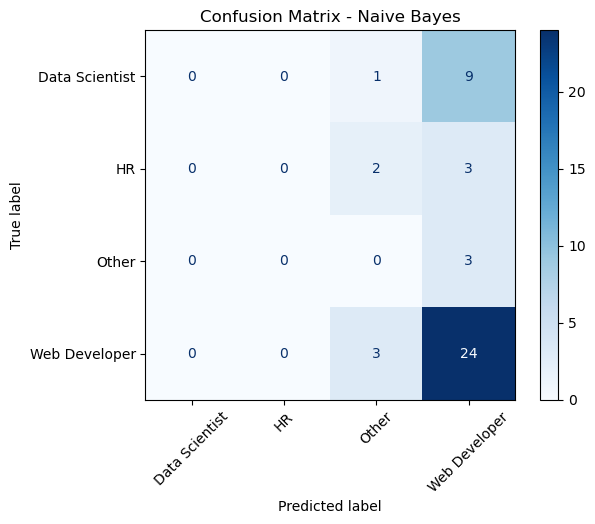


🔎 Model: Support Vector Machine
                precision    recall  f1-score   support

Data Scientist       1.00      0.10      0.18        10
            HR       0.00      0.00      0.00         5
         Other       0.14      0.33      0.20         3
 Web Developer       0.61      0.70      0.66        27

      accuracy                           0.47        45
     macro avg       0.44      0.28      0.26        45
  weighted avg       0.60      0.47      0.45        45



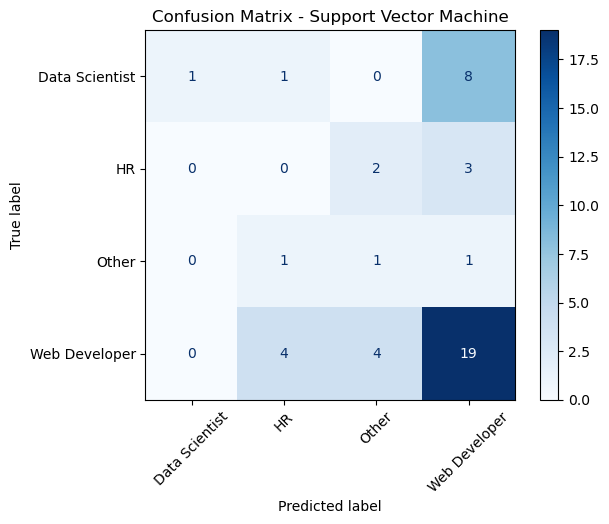


🔎 Model: Logistic Regression
                precision    recall  f1-score   support

Data Scientist       0.00      0.00      0.00        10
            HR       0.00      0.00      0.00         5
         Other       0.17      0.33      0.22         3
 Web Developer       0.63      0.89      0.74        27

      accuracy                           0.56        45
     macro avg       0.20      0.31      0.24        45
  weighted avg       0.39      0.56      0.46        45



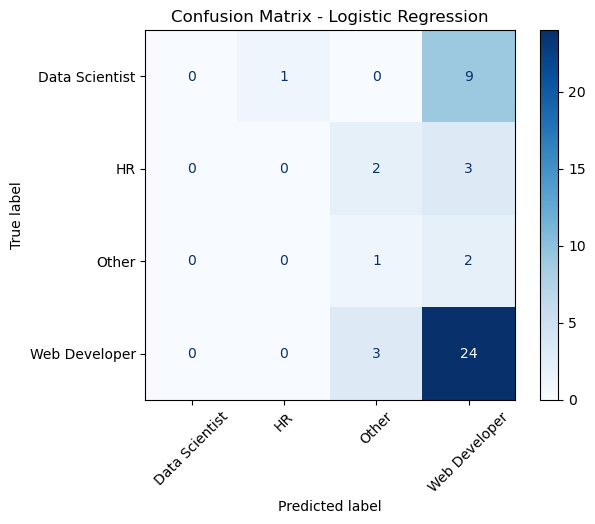

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# 1. Naive Bayes
train_and_evaluate(MultinomialNB(), "Naive Bayes")

# 2. SVM
train_and_evaluate(LinearSVC(dual=False), "Support Vector Machine")

# 3. Logistic Regression
train_and_evaluate(LogisticRegression(max_iter=1000), "Logistic Regression")


## Upgrade model with BERT embeddings for classification

### BERT Embeddings without Fine-Tuning

- Used `sentence-transformers` to generate pre-trained BERT embeddings for resume text.
- Trained and evaluated classification models (Naive Bayes, SVM, Logistic Regression) using BERT features.
- Fine-tuning was skipped as it's not required for small/medium-sized labeled datasets.

In [15]:
!pip install -U sentence-transformers

  Obtaining dependency information for sentence-transformers from https://files.pythonhosted.org/packages/6f/ff/178f08ea5ebc1f9193d9de7f601efe78c01748347875c8438f66f5cecc19/sentence_transformers-5.0.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/470.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/470.2 kB ? eta -:--:--
   --- ----------------------------------- 41.0/470.2 kB 653.6 kB/s eta 0:00:01
   ---------------------------------- ----- 409.6/470.2 kB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 470.2/470.2 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 4.1.0
    Uninstalling sentence-transformers-4.1.0:
      Successfully uninstalled sentence-transformers-4.1.0


In [16]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load BERT-based sentence transformer
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate BERT embeddings for each resume
X_bert = bert_model.encode(df['cleaned_content'], show_progress_bar=True)
y = df['Category']

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

### Train the Model

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_bert, y, test_size=0.2, random_state=42)


🔎 Model: Naive Bayes (BERT)
                precision    recall  f1-score   support

Data Scientist       0.47      0.80      0.59        10
            HR       0.15      0.40      0.22         5
         Other       0.14      0.33      0.20         3
 Web Developer       0.62      0.19      0.29        27

      accuracy                           0.36        45
     macro avg       0.35      0.43      0.33        45
  weighted avg       0.51      0.36      0.34        45



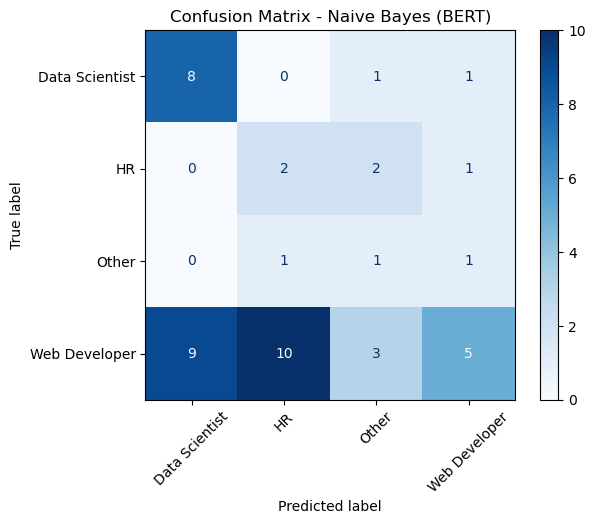


🔎 Model: SVM (BERT)
                precision    recall  f1-score   support

Data Scientist       0.00      0.00      0.00        10
            HR       0.00      0.00      0.00         5
         Other       1.00      0.33      0.50         3
 Web Developer       0.61      1.00      0.76        27

      accuracy                           0.62        45
     macro avg       0.40      0.33      0.32        45
  weighted avg       0.43      0.62      0.49        45



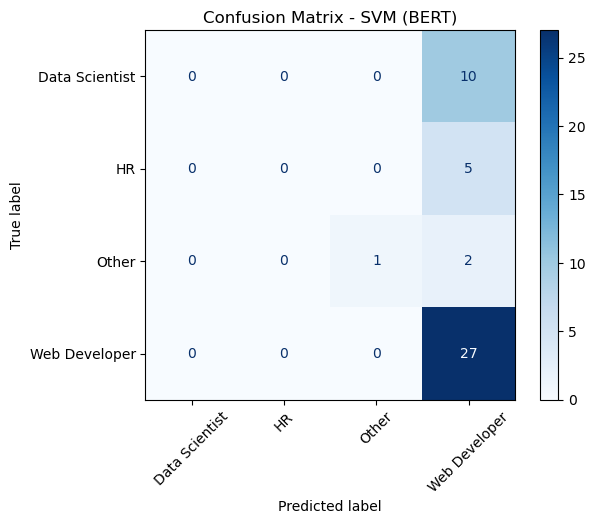


🔎 Model: Logistic Regression (BERT)
                precision    recall  f1-score   support

Data Scientist       0.00      0.00      0.00        10
            HR       0.00      0.00      0.00         5
         Other       0.50      0.33      0.40         3
 Web Developer       0.63      1.00      0.77        27

      accuracy                           0.62        45
     macro avg       0.28      0.33      0.29        45
  weighted avg       0.41      0.62      0.49        45



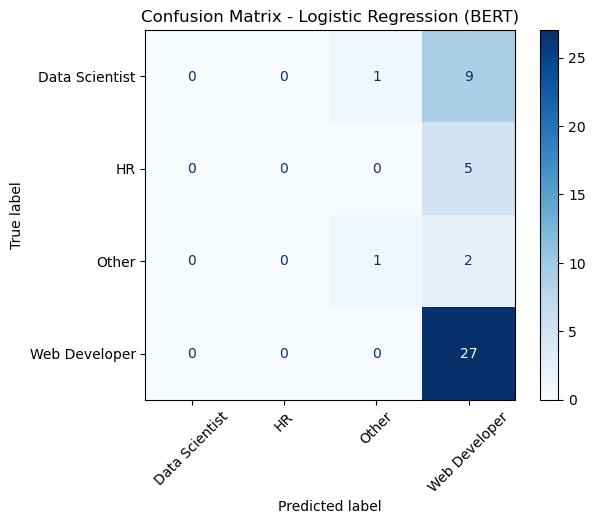

In [18]:
### 🤖 Model Training Using BERT Embeddings

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# 1. Naive Bayes (Gaussian works with dense vectors)
train_and_evaluate(GaussianNB(), "Naive Bayes (BERT)")

# 2. SVM
train_and_evaluate(SVC(kernel='linear'), "SVM (BERT)")

# 3. Logistic Regression
train_and_evaluate(LogisticRegression(max_iter=1000), "Logistic Regression (BERT)")

## Resume Uploader Interface & Model Deployment 

In [19]:
import pickle
from sklearn.linear_model import LogisticRegression

# Step 1: Train the model (if not already done)
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train, y_train)

# Step 2: Save the trained model
with open("model.pkl", "wb") as model_file:
    pickle.dump(final_model, model_file)

# Step 3: Save the TF-IDF vectorizer
with open("tfidf.pkl", "wb") as tfidf_file:
    pickle.dump(tfidf, tfidf_file)

In [20]:
model = pickle.load(open("model.pkl", "rb"))
tfidf = pickle.load(open("tfidf.pkl", "rb"))

In [21]:
!pip install streamlit

In [28]:
import streamlit as st
import os
import pickle
import docx
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import pandas as pd
import nltk

nltk.download('stopwords')

# Load model and TF-IDF
model = pickle.load(open("model.pkl", "rb"))
tfidf = pickle.load(open("tfidf.pkl", "rb"))

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Clean text
def preprocess(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text.lower())
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Read .docx content
def read_docx(file_path):
    doc = docx.Document(file_path)
    return '\n'.join([para.text for para in doc.paragraphs])

# Streamlit UI
st.title("📂 Batch Resume Screener")
st.write("This app scans **all .docx resumes** from your folder and shows predicted job roles.")

folder = "Resumes" 
if st.button("🔍 Scan All Resumes"):
    results = []
    for filename in os.listdir(folder):
        if filename.endswith(".docx"):
            path = os.path.join(folder, filename)
            try:
                text = read_docx(path)
                cleaned = preprocess(text)
                vector = tfidf.transform([cleaned])
                prediction = model.predict(vector)[0]
                results.append({"Resume": filename, "Predicted Role": prediction})
            except Exception as e:
                results.append({"Resume": filename, "Predicted Role": f"Error: {str(e)}"})

    if results:
        df = pd.DataFrame(results)
        st.dataframe(df)  
        st.success("✅ All resumes scanned.")
    else:
        st.warning("⚠️ No resumes found in the folder.")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2025-07-03 00:50:41.124 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-03 00:50:41.137 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-03 00:50:41.144 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-03 00:50:41.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-03 00:50:41.164 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-03 00:50:41.180 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-03 00:50:41.193 Thread 'MainThread': missing ScriptRunContext! This warning c